In [1]:
# mlp for regression
from numpy import sqrt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


/tmp/ipykernel_28255/460926942.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
2024-02-22 11:38:52.547970: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-02-22 11:38:52.550213: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-22 11:38:52.576232: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.c

In [5]:
# load the dataset
df = pd.read_csv('Data/trainign_dataset_51270_microarray_adjusted.csv')

# split into input and output columns
y = df['Age'].values
X = df.set_index('Sample', inplace=False)
X = X.drop(['Age', 'Experiment', 'Sex', "Status"], axis=1).values
# split into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)
#X_train = np.asarray(X_train).astype(np.float32)
#y_train = np.asarray(y_train).astype(np.float32)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(785, 1023) (388, 1023) (785,) (388,)


In [1]:
X[0]

NameError: name 'X' is not defined

In [24]:
# determine the number of input features
n_features = X_train.shape[1]
# define model
model = Sequential()
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_shape=(n_features,)))
model.add(Dense(8, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(1))
# compile the model
model.compile(optimizer='adam', loss='mse')
# fit the model
model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)


In [25]:
# evaluate the model
error = model.evaluate(X_test, y_test, verbose=0)
print('MSE: %.3f, RMSE: %.3f' % (error, sqrt(error)))
# make a prediction


MSE: 1034.347, RMSE: 32.161


In [26]:
X_new = X_test

# Make predictions using the trained model
predictions = model.predict(X_new)

# If your target variable is a single numeric value (regression), you can use predictions directly
# For example, if predictions is a 2D array, you can flatten it to a 1D array
predictions_flat = np.ravel(predictions)



13/13 [==============================] - 0s 582us/step


In [27]:
predictions_flat[0]


15.786167

In [28]:
results = pd.DataFrame(list(zip(y_test, predictions_flat)))
results

,0,1
0,50.60,15.786167
1,73.30,15.786167
2,53.90,15.786167
3,43.00,15.786167
4,29.80,15.786167
...,...,...
383,21.50,15.786167
384,31.05,15.786167
385,25.10,15.786167
386,52.22,15.786167


In [31]:
results=results.set_axis(["Actual", "Predicted"], axis=1)


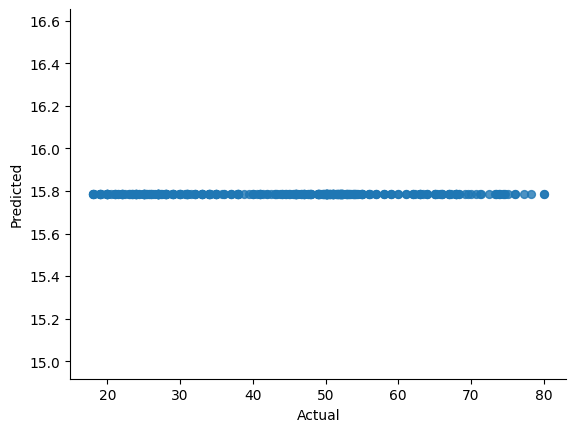

In [32]:
from matplotlib import pyplot as plt
results.plot(kind='scatter', x='Actual', y='Predicted', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)